# OpenCabinet Diffusion Policy Training (Colab GPU)

Self-contained notebook — trains a ~15M param 1D U-Net diffusion policy on augmented data.

**Setup:**
1. Zip your augmented data locally:
   ```
   cd <your_dataset_path>/lerobot
   zip -r augmented.zip augmented/
   ```
2. Upload `augmented.zip` to Google Drive root
3. Set runtime to **GPU** (Runtime → Change runtime type → T4 GPU)
4. Run all cells
5. Download `best_diffusion_policy.pt` and evaluate locally:
   ```
   python 07_evaluate_policy.py --checkpoint best_diffusion_policy.pt
   ```

In [1]:
import torch

assert torch.cuda.is_available(), "No GPU found! Go to Runtime > Change runtime type > T4 GPU"

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
!pip install -q diffusers einops pyarrow

In [3]:
# Mount Drive & extract data
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

DRIVE_ZIP = "/content/drive/MyDrive/augmented.zip"  # <-- update if different
DATA_DIR = "/content/augmented"

if not os.path.exists(DATA_DIR):
    print(f"Extracting {DRIVE_ZIP} ...")
    with zipfile.ZipFile(DRIVE_ZIP, 'r') as z:
        z.extractall('/content')
print(f"Parquet files: {len([f for f in os.listdir(DATA_DIR) if f.endswith('.parquet')])}")

Mounted at /content/drive
Extracting /content/drive/MyDrive/augmented.zip ...
Parquet files: 107


In [13]:
# === CONFIG ===
EPOCHS = 350
BATCH_SIZE = 128
LR = 1e-4
WEIGHT_DECAY = 1e-6
EMA_DECAY = 0.995
GRAD_CLIP = 1.0
LR_WARMUP_STEPS = 500

HORIZON = 16
N_OBS_STEPS = 2
N_ACTION_STEPS = 2

NUM_DIFFUSION_ITERS = 100
NUM_INFERENCE_ITERS = 16
BETA_SCHEDULE = "squaredcos_cap_v2"

# ~15M param U-Net
DOWN_DIMS = [128, 256, 512]
KERNEL_SIZE = 5
N_GROUPS = 8
DIFFUSION_STEP_EMBED_DIM = 256
COND_PREDICT_SCALE = True

OBS_NOISE_STD = 0.01
CHECKPOINT_DIR = "/content/checkpoints"

In [14]:
# ============================================================
#  All diffusion_policy modules (self-contained, no git clone)
# ============================================================
import copy, math, time
from typing import Dict, Union

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import einops
from einops import reduce
from einops.layers.torch import Rearrange
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler


# --- utils ---
def dict_apply(x, func):
    return {k: dict_apply(v, func) if isinstance(v, dict) else func(v) for k, v in x.items()}

class ModuleAttrMixin(nn.Module):
    def __init__(self):
        super().__init__()
        self._dummy_variable = nn.Parameter()
    @property
    def device(self):
        return next(iter(self.parameters())).device
    @property
    def dtype(self):
        return next(iter(self.parameters())).dtype

class DictOfTensorMixin(nn.Module):
    def __init__(self, params_dict=None):
        super().__init__()
        self.params_dict = params_dict if params_dict is not None else nn.ParameterDict()
    @property
    def device(self):
        return next(iter(self.parameters())).device
    def _load_from_state_dict(self, state_dict, prefix, local_metadata, strict, missing_keys, unexpected_keys, error_msgs):
        def dfs_add(dest, keys, value):
            if len(keys) == 1:
                dest[keys[0]] = value; return
            if keys[0] not in dest:
                dest[keys[0]] = nn.ParameterDict()
            dfs_add(dest[keys[0]], keys[1:], value)
        out = nn.ParameterDict()
        for key, value in state_dict.items():
            if key.startswith(prefix + 'params_dict'):
                param_keys = key[len(prefix + 'params_dict'):].split('.')[1:]
                dfs_add(out, param_keys, value.clone())
        self.params_dict = out
        self.params_dict.requires_grad_(False)


# --- Normalizer ---
def _fit(data, last_n_dims=1, dtype=torch.float32, mode='limits',
         output_max=1., output_min=-1., range_eps=1e-4, fit_offset=True):
    if isinstance(data, np.ndarray): data = torch.from_numpy(data)
    if dtype: data = data.type(dtype)
    dim = int(np.prod(data.shape[-last_n_dims:])) if last_n_dims > 0 else 1
    data = data.reshape(-1, dim)
    input_min, _ = data.min(0); input_max, _ = data.max(0)
    input_mean = data.mean(0); input_std = data.std(0)
    if mode == 'limits' and fit_offset:
        r = input_max - input_min; ign = r < range_eps
        r[ign] = output_max - output_min
        scale = (output_max - output_min) / r
        offset = output_min - scale * input_min
        offset[ign] = (output_max + output_min) / 2 - input_min[ign]
    else:
        scale = torch.ones_like(input_mean); offset = torch.zeros_like(input_mean)
    p = nn.ParameterDict({'scale': scale, 'offset': offset,
        'input_stats': nn.ParameterDict({'min': input_min, 'max': input_max, 'mean': input_mean, 'std': input_std})})
    for x in p.parameters(): x.requires_grad_(False)
    return p

def _normalize(x, params, forward=True):
    if isinstance(x, np.ndarray): x = torch.from_numpy(x)
    s, o = params['scale'], params['offset']
    x = x.to(device=s.device, dtype=s.dtype)
    sh = x.shape; x = x.reshape(-1, s.shape[0])
    x = x * s + o if forward else (x - o) / s
    return x.reshape(sh)

class SingleFieldLinearNormalizer(DictOfTensorMixin):
    def normalize(self, x): return _normalize(x, self.params_dict, True)
    def unnormalize(self, x): return _normalize(x, self.params_dict, False)

class LinearNormalizer(DictOfTensorMixin):
    @torch.no_grad()
    def fit(self, data, **kw):
        if isinstance(data, dict):
            for k, v in data.items(): self.params_dict[k] = _fit(v, **kw)
        else:
            self.params_dict['_default'] = _fit(data, **kw)
    def __getitem__(self, k): return SingleFieldLinearNormalizer(self.params_dict[k])
    def normalize(self, x):
        if isinstance(x, dict): return {k: _normalize(v, self.params_dict[k], True) for k, v in x.items()}
        return _normalize(x, self.params_dict['_default'], True)
    def unnormalize(self, x):
        if isinstance(x, dict): return {k: _normalize(v, self.params_dict[k], False) for k, v in x.items()}
        return _normalize(x, self.params_dict['_default'], False)


# --- Conv1D components ---
class Downsample1d(nn.Module):
    def __init__(self, dim): super().__init__(); self.conv = nn.Conv1d(dim, dim, 3, 2, 1)
    def forward(self, x): return self.conv(x)

class Upsample1d(nn.Module):
    def __init__(self, dim): super().__init__(); self.conv = nn.ConvTranspose1d(dim, dim, 4, 2, 1)
    def forward(self, x): return self.conv(x)

class Conv1dBlock(nn.Module):
    def __init__(self, inp, out, ks, n_groups=8):
        super().__init__()
        self.block = nn.Sequential(nn.Conv1d(inp, out, ks, padding=ks//2), nn.GroupNorm(n_groups, out), nn.Mish())
    def forward(self, x): return self.block(x)

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, x):
        h = self.dim // 2
        e = torch.exp(torch.arange(h, device=x.device) * -(math.log(10000) / (h - 1)))
        e = x[:, None] * e[None, :]
        return torch.cat((e.sin(), e.cos()), -1)


# --- Conditional Residual Block ---
class ConditionalResidualBlock1D(nn.Module):
    def __init__(self, ic, oc, cond_dim, kernel_size=3, n_groups=8, cond_predict_scale=False):
        super().__init__()
        self.blocks = nn.ModuleList([Conv1dBlock(ic, oc, kernel_size, n_groups), Conv1dBlock(oc, oc, kernel_size, n_groups)])
        cc = oc * 2 if cond_predict_scale else oc
        self.cond_predict_scale = cond_predict_scale; self.out_channels = oc
        self.cond_encoder = nn.Sequential(nn.Mish(), nn.Linear(cond_dim, cc), Rearrange('b t -> b t 1'))
        self.residual_conv = nn.Conv1d(ic, oc, 1) if ic != oc else nn.Identity()
    def forward(self, x, cond):
        out = self.blocks[0](x); emb = self.cond_encoder(cond)
        if self.cond_predict_scale:
            emb = emb.reshape(emb.shape[0], 2, self.out_channels, 1)
            out = emb[:,0] * out + emb[:,1]
        else:
            out = out + emb
        return self.blocks[1](out) + self.residual_conv(x)


# --- Conditional U-Net 1D ---
class ConditionalUnet1D(nn.Module):
    def __init__(self, input_dim, local_cond_dim=None, global_cond_dim=None,
                 diffusion_step_embed_dim=256, down_dims=[256,512,1024],
                 kernel_size=3, n_groups=8, cond_predict_scale=False):
        super().__init__()
        all_dims = [input_dim] + list(down_dims)
        dsed = diffusion_step_embed_dim
        self.diffusion_step_encoder = nn.Sequential(
            SinusoidalPosEmb(dsed), nn.Linear(dsed, dsed*4), nn.Mish(), nn.Linear(dsed*4, dsed))
        cond_dim = dsed + (global_cond_dim or 0)
        in_out = list(zip(all_dims[:-1], all_dims[1:]))
        kw = dict(kernel_size=kernel_size, n_groups=n_groups, cond_predict_scale=cond_predict_scale)
        self.local_cond_encoder = None
        if local_cond_dim is not None:
            _, d = in_out[0]
            self.local_cond_encoder = nn.ModuleList([
                ConditionalResidualBlock1D(local_cond_dim, d, cond_dim, **kw),
                ConditionalResidualBlock1D(local_cond_dim, d, cond_dim, **kw)])
        mid = all_dims[-1]
        self.mid_modules = nn.ModuleList([
            ConditionalResidualBlock1D(mid, mid, cond_dim, **kw),
            ConditionalResidualBlock1D(mid, mid, cond_dim, **kw)])
        self.down_modules = nn.ModuleList()
        for i, (di, do) in enumerate(in_out):
            self.down_modules.append(nn.ModuleList([
                ConditionalResidualBlock1D(di, do, cond_dim, **kw),
                ConditionalResidualBlock1D(do, do, cond_dim, **kw),
                Downsample1d(do) if i < len(in_out)-1 else nn.Identity()]))
        self.up_modules = nn.ModuleList()
        for i, (di, do) in enumerate(reversed(in_out[1:])):
            self.up_modules.append(nn.ModuleList([
                ConditionalResidualBlock1D(do*2, di, cond_dim, **kw),
                ConditionalResidualBlock1D(di, di, cond_dim, **kw),
                Upsample1d(di) if i < len(in_out)-1 else nn.Identity()]))
        self.final_conv = nn.Sequential(Conv1dBlock(down_dims[0], down_dims[0], kernel_size), nn.Conv1d(down_dims[0], input_dim, 1))

    def forward(self, sample, timestep, local_cond=None, global_cond=None, **kwargs):
        sample = einops.rearrange(sample, 'b h t -> b t h')
        ts = timestep if torch.is_tensor(timestep) else torch.tensor([timestep], dtype=torch.long, device=sample.device)
        if len(ts.shape) == 0: ts = ts[None]
        ts = ts.expand(sample.shape[0])
        gf = self.diffusion_step_encoder(ts)
        if global_cond is not None: gf = torch.cat([gf, global_cond], -1)
        hl = []
        if local_cond is not None:
            lc = einops.rearrange(local_cond, 'b h t -> b t h')
            hl = [self.local_cond_encoder[0](lc, gf), self.local_cond_encoder[1](lc, gf)]
        x, h = sample, []
        for i, (r1, r2, ds) in enumerate(self.down_modules):
            x = r1(x, gf)
            if i == 0 and hl: x = x + hl[0]
            x = r2(x, gf); h.append(x); x = ds(x)
        for m in self.mid_modules: x = m(x, gf)
        for i, (r1, r2, us) in enumerate(self.up_modules):
            x = torch.cat((x, h.pop()), 1); x = r1(x, gf)
            if i == len(self.up_modules) and hl: x = x + hl[1]
            x = r2(x, gf); x = us(x)
        return einops.rearrange(self.final_conv(x), 'b t h -> b h t')


# --- Mask Generator ---
class LowdimMaskGenerator(ModuleAttrMixin):
    def __init__(self, action_dim, obs_dim, max_n_obs_steps=2, fix_obs_steps=True, action_visible=False):
        super().__init__()
        self.action_dim = action_dim; self.obs_dim = obs_dim
        self.max_n_obs_steps = max_n_obs_steps; self.fix_obs_steps = fix_obs_steps
        self.action_visible = action_visible
    @torch.no_grad()
    def forward(self, shape, seed=None):
        dev = self.device; B, T, D = shape
        m = torch.zeros(shape, dtype=torch.bool, device=dev)
        ia = m.clone(); ia[..., :self.action_dim] = True; io = ~ia
        os_ = torch.full((B,), self.max_n_obs_steps, device=dev) if self.fix_obs_steps else \
              torch.randint(1, self.max_n_obs_steps+1, (B,), device=dev)
        steps = torch.arange(T, device=dev).unsqueeze(0).expand(B, T)
        return ((steps.T < os_).T.unsqueeze(-1).expand(B,T,D) & io)


# --- Diffusion Policy ---
class DiffusionUnetLowdimPolicy(ModuleAttrMixin):
    def __init__(self, model, noise_scheduler, horizon, obs_dim, action_dim,
                 n_action_steps, n_obs_steps, num_inference_steps=None,
                 obs_as_global_cond=True, pred_action_steps_only=False, **kwargs):
        super().__init__()
        self.model = model; self.noise_scheduler = noise_scheduler
        self.normalizer = LinearNormalizer()
        self.mask_generator = LowdimMaskGenerator(
            action_dim=action_dim, obs_dim=0 if obs_as_global_cond else obs_dim,
            max_n_obs_steps=n_obs_steps, fix_obs_steps=True, action_visible=False)
        self.horizon = horizon; self.obs_dim = obs_dim; self.action_dim = action_dim
        self.n_action_steps = n_action_steps; self.n_obs_steps = n_obs_steps
        self.obs_as_global_cond = obs_as_global_cond
        self.pred_action_steps_only = pred_action_steps_only
        self.num_inference_steps = num_inference_steps or noise_scheduler.config.num_train_timesteps
        self.kwargs = kwargs

    def set_normalizer(self, n): self.normalizer.load_state_dict(n.state_dict())

    def conditional_sample(self, cd, cm, local_cond=None, global_cond=None, generator=None, **kw):
        traj = torch.randn_like(cd)
        self.noise_scheduler.set_timesteps(self.num_inference_steps)
        for t in self.noise_scheduler.timesteps:
            traj[cm] = cd[cm]
            out = self.model(traj, t, local_cond=local_cond, global_cond=global_cond)
            traj = self.noise_scheduler.step(out, t, traj, generator=generator, **kw).prev_sample
        traj[cm] = cd[cm]
        return traj

    def predict_action(self, obs_dict):
        nobs = self.normalizer['obs'].normalize(obs_dict['obs'])
        B, _, Do = nobs.shape; To = self.n_obs_steps; Da = self.action_dim
        dev, dt = self.device, self.dtype
        gc = nobs[:,:To].reshape(B, -1)
        shape = (B, self.horizon, Da)
        cd = torch.zeros(shape, device=dev, dtype=dt)
        cm = torch.zeros_like(cd, dtype=torch.bool)
        ns = self.conditional_sample(cd, cm, global_cond=gc, **self.kwargs)
        ap = self.normalizer['action'].unnormalize(ns[...,:Da])
        return {'action': ap[:, To:To+self.n_action_steps], 'action_pred': ap}

    def compute_loss(self, batch):
        nb = self.normalizer.normalize(batch)
        obs, action = nb['obs'], nb['action']
        gc = obs[:,:self.n_obs_steps,:].reshape(obs.shape[0], -1)
        traj = action
        cm = torch.zeros_like(traj, dtype=torch.bool) if self.pred_action_steps_only else self.mask_generator(traj.shape)
        noise = torch.randn_like(traj)
        ts = torch.randint(0, self.noise_scheduler.config.num_train_timesteps, (traj.shape[0],), device=traj.device).long()
        noisy = self.noise_scheduler.add_noise(traj, noise, ts)
        noisy[cm] = traj[cm]
        pred = self.model(noisy, ts, global_cond=gc)
        target = noise if self.noise_scheduler.config.prediction_type == 'epsilon' else traj
        loss = F.mse_loss(pred, target, reduction='none') * (~cm).float()
        return reduce(loss, 'b ... -> b (...)', 'mean').mean()


print("All modules loaded.")

All modules loaded.


In [15]:
# ============================================================
#  Load dataset
# ============================================================
import pyarrow.parquet as pq
from torch.utils.data import Dataset, DataLoader

parquet_files = sorted(f for f in os.listdir(DATA_DIR) if f.endswith('.parquet'))
print(f"Found {len(parquet_files)} parquet files")

all_obs, all_actions = [], []

for pf in parquet_files:
    df = pq.read_table(os.path.join(DATA_DIR, pf)).to_pandas()
    state_cols = [c for c in df.columns if c.startswith('observation.state')]
    aug_cols = [c for c in ['observation.handle_pos', 'observation.handle_to_eef_pos',
                'observation.door_openness', 'observation.handle_xaxis',
                'observation.hinge_direction'] if c in df.columns]
    obs_cols = state_cols + aug_cols
    action_cols = [c for c in df.columns if c == 'action' or c.startswith('action.')]
    if not obs_cols or not action_cols: continue
    eo, ea = [], []
    for _, row in df.iterrows():
        op = []; ap = []
        for c in obs_cols:
            v = row[c]
            if isinstance(v, np.ndarray): op.extend(v.flatten().tolist())
            elif isinstance(v, (int, float, np.floating)): op.append(float(v))
        for c in action_cols:
            v = row[c]
            if isinstance(v, np.ndarray): ap.extend(v.flatten().tolist())
            elif isinstance(v, (int, float, np.floating)): ap.append(float(v))
        if op and ap: eo.append(op); ea.append(ap)
    if eo:
        all_obs.append(np.array(eo, dtype=np.float32))
        all_actions.append(np.array(ea, dtype=np.float32))

obs_dim = all_obs[0].shape[-1]
action_dim = all_actions[0].shape[-1]

indices = []
for i, ep in enumerate(all_obs):
    for t in range(N_OBS_STEPS - 1, len(ep) - HORIZON + 1):
        indices.append((i, t))

print(f"Episodes: {len(all_obs)}, Obs dim: {obs_dim}, Action dim: {action_dim}")
print(f"Training windows: {len(indices)}")


class CabinetDataset(Dataset):
    def __len__(self): return len(indices)
    def __getitem__(self, idx):
        ei, t = indices[idx]
        obs = all_obs[ei][t - N_OBS_STEPS + 1 : t + 1].copy()
        act = all_actions[ei][t : t + HORIZON]
        if len(act) < HORIZON:
            act = np.concatenate([act, np.repeat(act[-1:], HORIZON - len(act), 0)])
        # Add observation noise for better generalization
        if OBS_NOISE_STD > 0:
            obs = obs + np.random.randn(*obs.shape).astype(np.float32) * OBS_NOISE_STD
        return {'obs': torch.from_numpy(obs), 'action': torch.from_numpy(act)}


dataset = CabinetDataset()
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        drop_last=True, num_workers=2, pin_memory=True)
print(f"Batches/epoch: {len(dataloader)}")

Found 107 parquet files
Episodes: 107, Obs dim: 27, Action dim: 12
Training windows: 35780
Batches/epoch: 279


In [16]:
# ============================================================
#  Build model (~15M params)
# ============================================================
device = torch.device('cuda')

normalizer = LinearNormalizer()
normalizer.fit(data={
    'obs': torch.from_numpy(np.concatenate(all_obs)).float(),
    'action': torch.from_numpy(np.concatenate(all_actions)).float(),
}, mode='limits', output_max=1.0, output_min=-1.0)

noise_scheduler = DDPMScheduler(
    num_train_timesteps=NUM_DIFFUSION_ITERS, beta_schedule=BETA_SCHEDULE,
    clip_sample=True, prediction_type='epsilon')

unet = ConditionalUnet1D(
    input_dim=action_dim, global_cond_dim=obs_dim * N_OBS_STEPS,
    diffusion_step_embed_dim=DIFFUSION_STEP_EMBED_DIM, down_dims=DOWN_DIMS,
    kernel_size=KERNEL_SIZE, n_groups=N_GROUPS, cond_predict_scale=COND_PREDICT_SCALE)

policy = DiffusionUnetLowdimPolicy(
    model=unet, noise_scheduler=noise_scheduler,
    horizon=HORIZON, obs_dim=obs_dim, action_dim=action_dim,
    n_action_steps=N_ACTION_STEPS, n_obs_steps=N_OBS_STEPS,
    num_inference_steps=NUM_INFERENCE_ITERS, obs_as_global_cond=True)

policy.set_normalizer(normalizer)
policy = policy.to(device)
ema_policy = copy.deepcopy(policy); ema_policy.eval()

n_params = sum(p.numel() for p in policy.parameters())
print(f"Model: {n_params:,} params ({n_params/1e6:.1f}M)")

Model: 18,026,870 params (18.0M)


In [17]:
# ============================================================
#  Train
# ============================================================
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

optimizer = torch.optim.AdamW(policy.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = EPOCHS * len(dataloader)

def lr_lambda(step):
    if step < LR_WARMUP_STEPS: return step / max(LR_WARMUP_STEPS, 1)
    return 0.5 * (1 + np.cos(np.pi * (step - LR_WARMUP_STEPS) / max(total_steps - LR_WARMUP_STEPS, 1)))

lr_sched = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
best_loss = float('inf')
loss_history = []

print(f"Training: {EPOCHS} epochs, {len(dataloader)} batches/epoch, {total_steps} total steps")
print(f"U-Net dims: {DOWN_DIMS}, ~{n_params/1e6:.0f}M params")
print("-" * 60)
t0 = time.time()

for epoch in range(EPOCHS):
    policy.train(); el = 0; nb = 0
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = policy.compute_loss(batch)
        optimizer.zero_grad(); loss.backward()
        if GRAD_CLIP > 0: torch.nn.utils.clip_grad_norm_(policy.parameters(), GRAD_CLIP)
        optimizer.step(); lr_sched.step()
        with torch.no_grad():
            for pe, p in zip(ema_policy.parameters(), policy.parameters()):
                pe.data.mul_(EMA_DECAY).add_(p.data, alpha=1 - EMA_DECAY)
        el += loss.item(); nb += 1
    avg = el / max(nb, 1); loss_history.append(avg)
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  Loss: {avg:.6f}  LR: {optimizer.param_groups[0]['lr']:.2e}  [{(time.time()-t0)/60:.1f}m]")
    if avg < best_loss:
        best_loss = avg
        torch.save({
            'policy_type': 'diffusion_unet', 'epoch': epoch, 'loss': best_loss,
            'obs_dim': obs_dim, 'action_dim': action_dim, 'state_dim': obs_dim,
            'policy_state_dict': ema_policy.state_dict(),
            'config': {'horizon': HORIZON, 'n_obs_steps': N_OBS_STEPS, 'n_action_steps': N_ACTION_STEPS,
                       'num_diffusion_iters': NUM_DIFFUSION_ITERS, 'num_inference_iters': NUM_INFERENCE_ITERS,
                       'beta_schedule': BETA_SCHEDULE, 'down_dims': DOWN_DIMS, 'kernel_size': KERNEL_SIZE,
                       'n_groups': N_GROUPS, 'diffusion_step_embed_dim': DIFFUSION_STEP_EMBED_DIM,
                       'cond_predict_scale': COND_PREDICT_SCALE},
        }, os.path.join(CHECKPOINT_DIR, 'best_diffusion_policy.pt'))

print(f"\nDone! {(time.time()-t0)/60:.1f} min. Best loss: {best_loss:.6f}")

Training: 350 epochs, 279 batches/epoch, 97650 total steps
U-Net dims: [128, 256, 512], ~18M params
------------------------------------------------------------
Epoch   1/350  Loss: 0.842518  LR: 5.58e-05  [0.2m]
Epoch   5/350  Loss: 0.067666  LR: 1.00e-04  [1.1m]
Epoch  10/350  Loss: 0.043361  LR: 9.99e-05  [2.3m]
Epoch  15/350  Loss: 0.036663  LR: 9.96e-05  [3.5m]
Epoch  20/350  Loss: 0.034326  LR: 9.93e-05  [4.6m]
Epoch  25/350  Loss: 0.032420  LR: 9.89e-05  [5.8m]
Epoch  30/350  Loss: 0.031058  LR: 9.84e-05  [6.9m]
Epoch  35/350  Loss: 0.029182  LR: 9.78e-05  [8.1m]
Epoch  40/350  Loss: 0.028512  LR: 9.71e-05  [9.2m]
Epoch  45/350  Loss: 0.026933  LR: 9.62e-05  [10.4m]
Epoch  50/350  Loss: 0.026119  LR: 9.53e-05  [11.5m]
Epoch  55/350  Loss: 0.024765  LR: 9.43e-05  [12.7m]
Epoch  60/350  Loss: 0.023720  LR: 9.33e-05  [13.8m]
Epoch  65/350  Loss: 0.022381  LR: 9.21e-05  [15.0m]
Epoch  70/350  Loss: 0.022074  LR: 9.08e-05  [16.2m]
Epoch  75/350  Loss: 0.020906  LR: 8.95e-05  [17.3m]


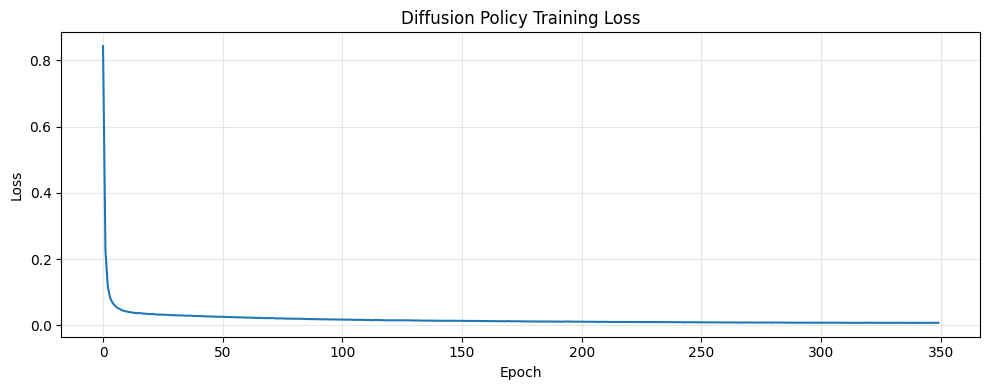

In [18]:
# Loss curve
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Diffusion Policy Training Loss')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [19]:
# Save to Drive & download
import shutil

ckpt = os.path.join(CHECKPOINT_DIR, 'best_diffusion_policy.pt')
print(f"Checkpoint: {os.path.getsize(ckpt)/1e6:.1f} MB")

# Copy to Drive
drive_dir = '/content/drive/MyDrive/cabinet_checkpoints'
os.makedirs(drive_dir, exist_ok=True)
shutil.copy2(ckpt, drive_dir)
print(f"Saved to: {drive_dir}/best_diffusion_policy.pt")

# Download to local machine
from google.colab import files
files.download(ckpt)

print("\nEvaluate locally:")
print("  python 07_evaluate_policy.py --checkpoint best_diffusion_policy.pt")

Checkpoint: 72.2 MB
Saved to: /content/drive/MyDrive/cabinet_checkpoints/best_diffusion_policy.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Evaluate locally:
  python 07_evaluate_policy.py --checkpoint best_diffusion_policy.pt
